In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
df = pd.read_csv('../data/Churn_Modelling.csv')

In [5]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [10]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
df_transformed = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True, dtype=np.int64)
df_transformed

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,1,0


In [12]:
x = df_transformed.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11]]
y = df_transformed.iloc[:, 8]

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [14]:
st_balance = StandardScaler()
x_train = st_balance.fit_transform(x_train)
x_test = st_balance.transform(x_test)

In [15]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

In [16]:
model = nn.Sequential(
    nn.Linear(11, 3),
    nn.Sigmoid(),
    nn.Linear(3, 1),
    nn.Sigmoid()
)
model

Sequential(
  (0): Linear(in_features=11, out_features=3, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=3, out_features=1, bias=True)
  (3): Sigmoid()
)

In [17]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [18]:
for epoch in range(10):
    model.train()
    optimizer.zero_grad()
    y_pred = model(x_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch + 1}/10, Loss: {loss.item():.4f}')

Epoch 1/10, Loss: 0.7544
Epoch 2/10, Loss: 0.7443
Epoch 3/10, Loss: 0.7343
Epoch 4/10, Loss: 0.7245
Epoch 5/10, Loss: 0.7149
Epoch 6/10, Loss: 0.7055
Epoch 7/10, Loss: 0.6963
Epoch 8/10, Loss: 0.6872
Epoch 9/10, Loss: 0.6784
Epoch 10/10, Loss: 0.6698


In [19]:
model.eval()
with torch.no_grad():
    y_log = model(x_test_tensor).numpy()
y_log

array([[0.4740258 ],
       [0.4827599 ],
       [0.46705413],
       ...,
       [0.4486571 ],
       [0.4841327 ],
       [0.49812308]], shape=(2000, 1), dtype=float32)

In [20]:
y_log_prediction = np.where(y_log > 0.5, 1, 0)
accuracy_score(y_test, y_log_prediction)

0.7745

In [21]:
for name, param in model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([3, 11])
0.bias torch.Size([3])
2.weight torch.Size([1, 3])
2.bias torch.Size([1])


In [22]:
model2 = nn.Sequential(
    nn.Linear(11, 11),
    nn.ReLU(),
    nn.Linear(11, 11),
    nn.ReLU(),
    nn.Linear(11, 1),
    nn.Sigmoid()
)
model2

Sequential(
  (0): Linear(in_features=11, out_features=11, bias=True)
  (1): ReLU()
  (2): Linear(in_features=11, out_features=11, bias=True)
  (3): ReLU()
  (4): Linear(in_features=11, out_features=1, bias=True)
  (5): Sigmoid()
)

In [23]:
x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=1
)

x_train_sub_tensor = torch.tensor(x_train_sub, dtype=torch.float32)
y_train_sub_tensor = torch.tensor(y_train_sub.values.reshape(-1, 1), dtype=torch.float32)
x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values.reshape(-1, 1), dtype=torch.float32)

In [24]:
criterion2 = nn.BCELoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.01)

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(100):
    model2.train()
    optimizer2.zero_grad()
    train_pred = model2(x_train_sub_tensor)
    train_loss = criterion2(train_pred, y_train_sub_tensor)
    train_loss.backward()
    optimizer2.step()

    model2.eval()
    with torch.no_grad():
        val_pred = model2(x_val_tensor)
        val_loss = criterion2(val_pred, y_val_tensor)

        train_acc = ((train_pred > 0.5).float() == y_train_sub_tensor).float().mean().item()
        val_acc = ((val_pred > 0.5).float() == y_val_tensor).float().mean().item()

    history['loss'].append(train_loss.item())
    history['val_loss'].append(val_loss.item())
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}/100 | Loss: {train_loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
        )

Epoch 10/100 | Loss: 0.5920 | Val Loss: 0.5770 | Acc: 0.7980 | Val Acc: 0.7937
Epoch 20/100 | Loss: 0.4805 | Val Loss: 0.4859 | Acc: 0.7981 | Val Acc: 0.7937
Epoch 30/100 | Loss: 0.4497 | Val Loss: 0.4545 | Acc: 0.7981 | Val Acc: 0.7937
Epoch 40/100 | Loss: 0.4367 | Val Loss: 0.4451 | Acc: 0.7981 | Val Acc: 0.7937
Epoch 50/100 | Loss: 0.4280 | Val Loss: 0.4393 | Acc: 0.7981 | Val Acc: 0.7937
Epoch 60/100 | Loss: 0.4227 | Val Loss: 0.4356 | Acc: 0.7981 | Val Acc: 0.7937
Epoch 70/100 | Loss: 0.4162 | Val Loss: 0.4310 | Acc: 0.8122 | Val Acc: 0.8062
Epoch 80/100 | Loss: 0.4084 | Val Loss: 0.4243 | Acc: 0.8189 | Val Acc: 0.8050
Epoch 90/100 | Loss: 0.3990 | Val Loss: 0.4158 | Acc: 0.8258 | Val Acc: 0.8100
Epoch 100/100 | Loss: 0.3885 | Val Loss: 0.4084 | Acc: 0.8261 | Val Acc: 0.8112


In [25]:
model2.eval()
with torch.no_grad():
    y_log2 = model2(x_test_tensor).numpy()
y_log_prediction2 = np.where(y_log2 > 0.5, 1, 0)
accuracy_score(y_test, y_log_prediction2)

0.8225

In [26]:
history

{'loss': [0.7759206891059875,
  0.7518631815910339,
  0.7298225164413452,
  0.7090144157409668,
  0.6888989806175232,
  0.6691774129867554,
  0.6496227979660034,
  0.6301578879356384,
  0.6108880043029785,
  0.5920001864433289,
  0.5737369656562805,
  0.5563792586326599,
  0.540306806564331,
  0.5258496403694153,
  0.5132721066474915,
  0.502821147441864,
  0.49452751874923706,
  0.4882858991622925,
  0.48375946283340454,
  0.4804646968841553,
  0.47788238525390625,
  0.4755379557609558,
  0.4730221629142761,
  0.4701705574989319,
  0.4669348895549774,
  0.46342337131500244,
  0.45980149507522583,
  0.4562184810638428,
  0.45282599329948425,
  0.44973891973495483,
  0.4470515549182892,
  0.4447818100452423,
  0.4429318904876709,
  0.44147181510925293,
  0.44034141302108765,
  0.43942946195602417,
  0.4386948049068451,
  0.4380396008491516,
  0.43739068508148193,
  0.4367058277130127,
  0.43594658374786377,
  0.4351077973842621,
  0.43420228362083435,
  0.43324074149131775,
  0.43226101

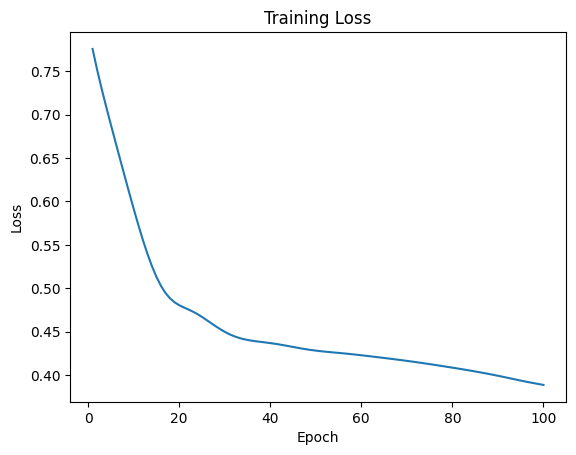

In [27]:
sns.lineplot(x=range(1, len(history['loss']) + 1), y=history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

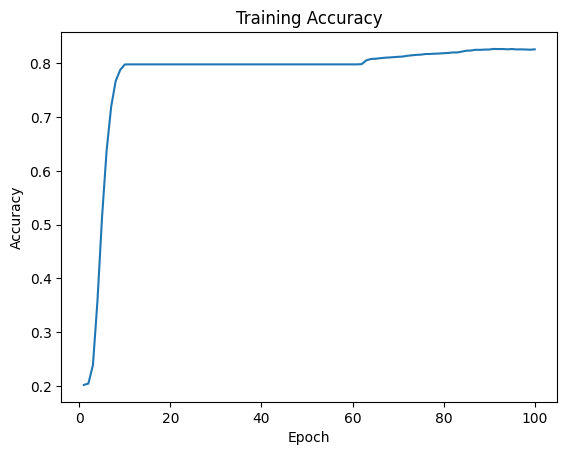

In [28]:
sns.lineplot(x=range(1, len(history['accuracy']) + 1), y=history['accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [29]:
import plotly.express as px
import pandas as pd

metrics_df = pd.DataFrame({
    'epoch': range(1, len(history['accuracy']) + 1),
    'accuracy': history['accuracy'],
    'val_accuracy': history['val_accuracy'],
    'loss': history['loss'],
    'val_loss': history['val_loss']
})

In [30]:
fig_acc = px.line(metrics_df, x='epoch', y=['accuracy', 'val_accuracy'], title='Accuracy over Epochs')
fig_acc.show()

fig_loss = px.line(metrics_df, x='epoch', y=['loss', 'val_loss'], title='Loss over Epochs')
fig_loss.show()